<a href="https://colab.research.google.com/github/CUHK-DH-Lab/YCRG_Cross-Cultural_Analytics/blob/main/PG_DH_Week_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Group 2

In [ ]:
# Install DVT and Google Vision
!pip install dvt google-cloud-vision

import os
import io
import dvt
import matplotlib.pyplot as plt
from PIL import Image as PILImage
from google.cloud import vision

# 1. Set credentials
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "/content/renaissance-ocr-4aabe5b8dc65.json"
client = vision.ImageAnnotatorClient()



Success: Image file downloaded.

--- Displaying Stagecoach (1939) ---


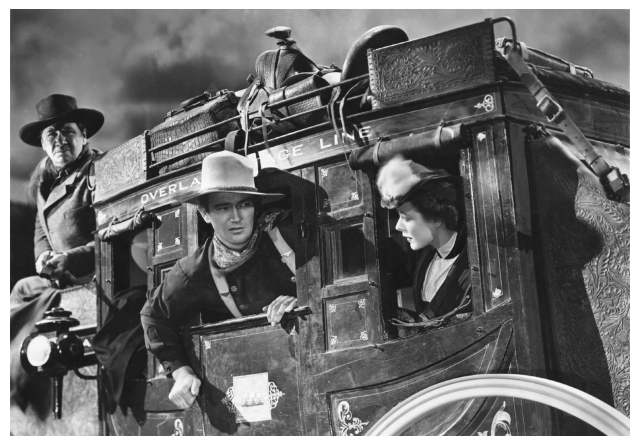


Google Vision Identifications:
- Hat (97.75% confidence)
- Sun hat (91.82% confidence)
- Black (90.63% confidence)
- Monochrome photography (88.48% confidence)
- Black and white (83.93% confidence)
- Monochrome (83.11% confidence)
- Fedora (80.59% confidence)
- Cowboy hat (77.37% confidence)
- Vintage clothing (67.54% confidence)
- Retro style (59.89% confidence)


In [ ]:

import os
import io
import requests
import dvt
import matplotlib.pyplot as plt
from google.cloud import vision

# 2. Setup Google Vision Authentication
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "/content/renaissance-ocr-4aabe5b8dc65.json"
client = vision.ImageAnnotatorClient()

def process_and_identify(image_url):
    local_filename = "stagecoach_final.jpg"

    # 3. FIX: Mimic a browser to avoid 403 Forbidden errors
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/110.0.0.0 Safari/537.36',
        'Accept': 'image/avif,image/webp,image/apng,image/svg+xml,image/*,*/*;q=0.8'
    }

    try:
        print(f"Downloading from: {image_url}")
        response = requests.get(image_url, headers=headers, timeout=15)
        response.raise_for_status()

        with open(local_filename, 'wb') as f:
            f.write(response.content)
        print("Success: Image file downloaded.")

    except Exception as e:
        print(f"Download failed: {e}")
        return

    # 4. Load and Display using DVT
    # dvt.load_image will now find actual pixel data
    img_array = dvt.load_image(local_filename)

    print("\n--- Displaying Stagecoach (1939) ---")
    plt.figure(figsize=(8, 6))
    plt.imshow(img_array)
    plt.axis('off')
    plt.show()

    # 5. Identify with Google Vision
    with io.open(local_filename, 'rb') as image_file:
        content = image_file.read()

    image = vision.Image(content=content)
    vision_response = client.label_detection(image=image)
    labels = vision_response.label_annotations

    print("\nGoogle Vision Identifications:")
    for label in labels:
        print(f"- {label.description} ({label.score:.2%} confidence)")

# 6. RUN WITH THE CORRECT DIRECT URL
# This link points to the actual .jpg file, not the website
stagecoach_direct_url = "https://upload.wikimedia.org/wikipedia/commons/2/25/Stagecoach-1939.jpg"
process_and_identify(stagecoach_direct_url)


Success: Image downloaded for analysis.

--- Displaying Stagecoach (1939) ---


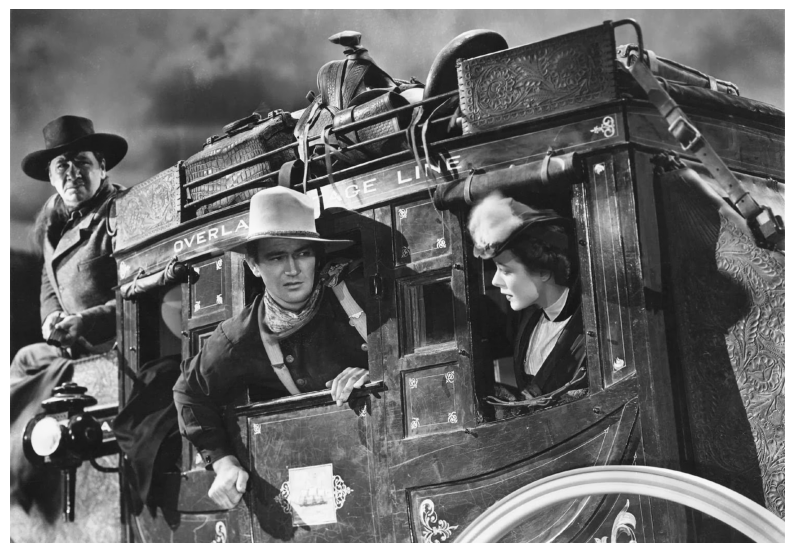

Detected 3 face(s):

--- Person #1 ---
  - Joy: VERY_UNLIKELY
  - Sorrow: VERY_UNLIKELY
  - Anger: VERY_UNLIKELY
  - Surprise: VERY_UNLIKELY
  - Wearing Headwear: VERY_LIKELY

--- Person #2 ---
  - Joy: VERY_UNLIKELY
  - Sorrow: VERY_UNLIKELY
  - Anger: VERY_UNLIKELY
  - Surprise: VERY_UNLIKELY
  - Wearing Headwear: UNLIKELY

--- Person #3 ---
  - Joy: VERY_UNLIKELY
  - Sorrow: VERY_UNLIKELY
  - Anger: VERY_UNLIKELY
  - Surprise: VERY_UNLIKELY
  - Wearing Headwear: VERY_LIKELY


In [ ]:
import os
import io
import requests
import dvt
import matplotlib.pyplot as plt
from google.cloud import vision

# 2. Setup Google Vision Authentication
# Ensure 'renaissance-ocr-4aabe5b8dc65.json' is uploaded to the /content/ folder
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "/content/renaissance-ocr-4aabe5b8dc65.json"
client = vision.ImageAnnotatorClient()

def analyze_stagecoach_faces(image_url):
    local_filename = "stagecoach_analysis.jpg"

    # 3. Comprehensive headers to bypass 403 Forbidden errors
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/110.0.0.0 Safari/537.36',
        'Accept': 'text/html,application/xhtml+xml,application/xml;q=0.9,image/avif,image/webp,image/apng,*/*;q=0.8',
        'Accept-Language': 'en-US,en;q=0.9',
        'Referer': 'https://commons.wikimedia.org'
    }

    try:
        print(f"Downloading from: {image_url}")
        response = requests.get(image_url, headers=headers, timeout=20)
        response.raise_for_status()

        with open(local_filename, 'wb') as f:
            f.write(response.content)
        print("Success: Image downloaded for analysis.")

    except Exception as e:
        print(f"Download failed: {e}")
        return

    # 4. Load and Display using DVT
    img_array = dvt.load_image(local_filename)

    print("\n--- Displaying Stagecoach (1939) ---")
    plt.figure(figsize=(10, 7))
    plt.imshow(img_array)
    plt.axis('off')
    plt.show()

    # 5. Perform Face & Emotion Detection
    with io.open(local_filename, 'rb') as image_file:
        content = image_file.read()

    image = vision.Image(content=content)
    # Using face_detection specifically
    vision_response = client.face_detection(image=image)
    faces = vision_response.face_annotations

    # Mapping likelihood levels for readability
    likelihood_name = ('UNKNOWN', 'VERY_UNLIKELY', 'UNLIKELY', 'POSSIBLE', 'LIKELY', 'VERY_LIKELY')

    print(f"Detected {len(faces)} face(s):")
    for i, face in enumerate(faces):
        print(f"\n--- Person #{i+1} ---")
        print(f"  - Joy: {likelihood_name[face.joy_likelihood]}")
        print(f"  - Sorrow: {likelihood_name[face.sorrow_likelihood]}")
        print(f"  - Anger: {likelihood_name[face.anger_likelihood]}")
        print(f"  - Surprise: {likelihood_name[face.surprise_likelihood]}")
        print(f"  - Wearing Headwear: {likelihood_name[face.headwear_likelihood]}")

# 6. DIRECT URL: Ensure this is the full path to the .jpg file
stagecoach_url = "https://upload.wikimedia.org/wikipedia/commons/2/25/Stagecoach-1939.jpg"

# Run the analysis
analyze_stagecoach_faces(stagecoach_url)


Success: Image downloaded for localization.

--- Displaying Stagecoach (1939) ---


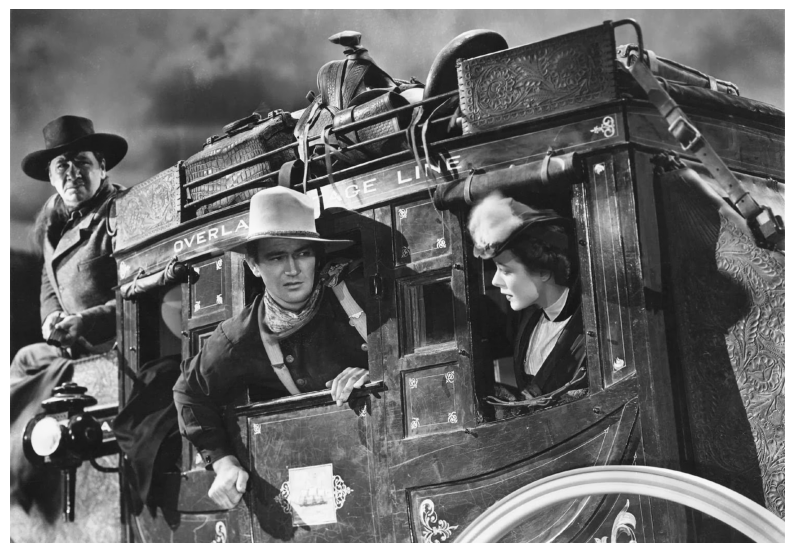

Detected 10 object(s):
- Clothing (Confidence: 80.41%)
- Fedora (Confidence: 76.55%)
- Clothing (Confidence: 76.50%)
- Hat (Confidence: 70.21%)
- Clothing (Confidence: 67.46%)
- Sun hat (Confidence: 67.09%)
- Person (Confidence: 66.52%)
- Person (Confidence: 66.17%)
- Person (Confidence: 66.08%)
- Fedora (Confidence: 63.93%)


In [ ]:

import os
import io
import requests
import dvt
import matplotlib.pyplot as plt
from google.cloud import vision

# 2. Setup Google Vision Authentication
# Ensure 'renaissance-ocr-4aabe5b8dc65.json' is uploaded to the /content/ folder
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "/content/renaissance-ocr-4aabe5b8dc65.json"
client = vision.ImageAnnotatorClient()

def localize_stagecoach_objects(image_url):
    local_filename = "stagecoach_objects.jpg"

    # 3. Comprehensive headers to bypass 403 Forbidden errors
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/110.0.0.0 Safari/537.36',
        'Referer': 'https://commons.wikimedia.org'
    }

    try:
        print(f"Downloading from: {image_url}")
        response = requests.get(image_url, headers=headers, timeout=20)
        response.raise_for_status()
        with open(local_filename, 'wb') as f:
            f.write(response.content)
        print("Success: Image downloaded for localization.")
    except Exception as e:
        print(f"Download failed: {e}")
        return

    # 4. Load and Display using DVT
    img_array = dvt.load_image(local_filename)

    print("\n--- Displaying Stagecoach (1939) ---")
    plt.figure(figsize=(10, 7))
    plt.imshow(img_array)
    plt.axis('off')
    plt.show()

    # 5. Perform Object Localization
    with io.open(local_filename, 'rb') as image_file:
        content = image_file.read()

    image = vision.Image(content=content)
    # Using object_localization specifically
    response = client.object_localization(image=image)
    objects = response.localized_object_annotations

    print(f"Detected {len(objects)} object(s):")
    if not objects:
        print("No specific objects localized.")
    else:
        for obj in objects:
            print(f"- {obj.name} (Confidence: {obj.score:.2%})")
            # The API also provides 'obj.bounding_poly' for drawing boxes if needed

# 6. DIRECT URL: This points to the actual .jpg file
# Corrected path to the Stagecoach file on Wikimedia servers
stagecoach_url = "https://upload.wikimedia.org/wikipedia/commons/2/25/Stagecoach-1939.jpg"

# Run the analysis
localize_stagecoach_objects(stagecoach_url)


Group 3


# **Robot Art Historian Pipeline**
Can we produce a pipeline to automate Panofsky's three levels of iconography?

**Pre-Iconographical Description (Primary Matter)**

Success: Binary image data secured.

--- LEVEL 1: EMPIRICAL VISUAL EVIDENCE ---


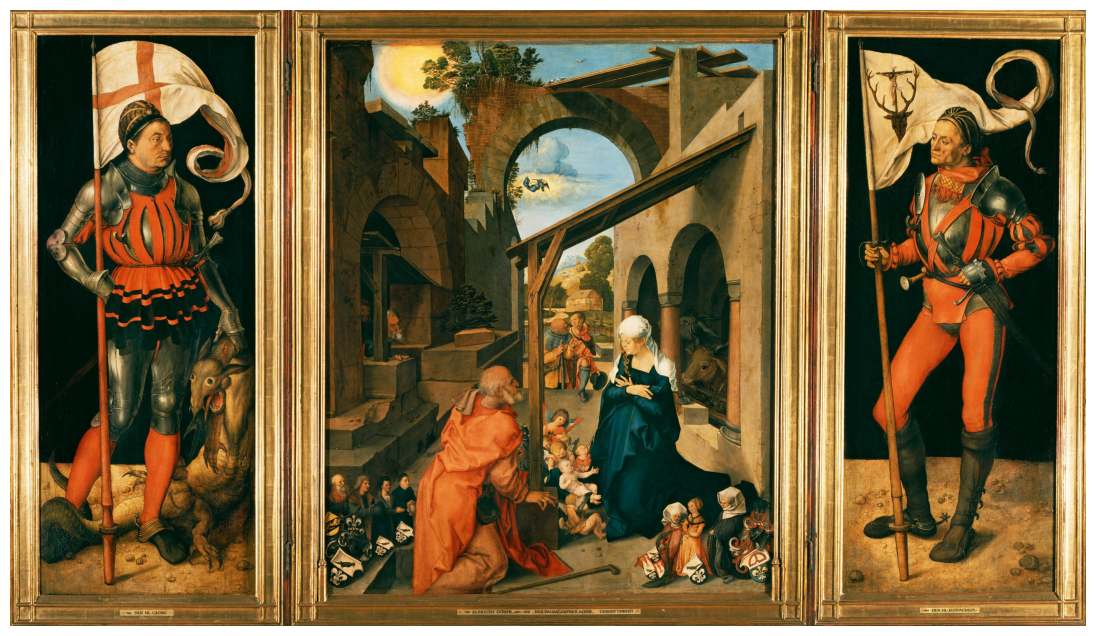


--- MACHINE-IDENTIFIED LABELS ---
Art, Visual arts, Painting, Mythology, Modern art, Fictional character, Prophet, Middle Ages, Picture frame

--- MACHINE-IDENTIFIED OBJECTS ---
Painting, Painting, Painting, Picture frame, Picture frame, Picture frame

--- MACHINE-DETECTED OCR TEXT ---
701 DER HL GEORG
706 ALBRECHT DURER 1471-1525 DER PAUMGARTNER ALTAR GEBURT CHRISTI
703 DER HL-EUSTACHIUS

--- DOMINANT COLORS ---
RGB(58, 49, 23), RGB(181, 150, 94), RGB(102, 81, 33)


In [ ]:
import requests

def get_level_1_data(image_url):
    local_path = "paumgartner_altarpiece.jpg"
    # Wikimedia-compliant headers
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/115.0.0.0 Safari/537.36'
    }

    # 1. Data Acquisition
    try:
        resp = requests.get(image_url, headers=headers, timeout=20)
        resp.raise_for_status()
        with open(local_path, 'wb') as f: f.write(resp.content)
        print("Success: Binary image data secured.")
    except Exception as e:
        print(f"Data acquisition failed: {e}")
        return None, None, None, None

    # 2. Visual Rendering (DVT)
    img_array = dvt.load_image(local_path)
    print("\n--- LEVEL 1: EMPIRICAL VISUAL EVIDENCE ---")
    plt.figure(figsize=(14, 8))
    plt.imshow(img_array)
    plt.axis('off')
    plt.show()

    # 3. Machine Extraction (Google Vision)
    with io.open(local_path, 'rb') as f: content = f.read()
    image = vision.Image(content=content)

    # Run detections: Labels, Objects, Properties, and OCR
    labels_res = client.label_detection(image=image).label_annotations
    objects_res = client.object_localization(image=image).localized_object_annotations
    props_res = client.image_properties(image=image).image_properties_annotation
    text_res = client.text_detection(image=image).text_annotations

    # Format metadata
    labels = [l.description for l in labels_res]
    objects = [o.name for o in objects_res]
    ocr_text = text_res[0].description if text_res else "No text detected."

    # Extract dominant RGB colors
    colors = []
    if props_res.dominant_colors.colors:
        for c in props_res.dominant_colors.colors[:3]:
            r, g, b = int(c.color.red), int(c.color.green), int(c.color.blue)
            colors.append(f"RGB({r}, {g}, {b})")

    # 4. Print identified results for verification
    print("\n--- MACHINE-IDENTIFIED LABELS ---")
    print(", ".join(labels))

    print("\n--- MACHINE-IDENTIFIED OBJECTS ---")
    print(", ".join(objects))

    print("\n--- MACHINE-DETECTED OCR TEXT ---")
    print(ocr_text)

    print(f"\n--- DOMINANT COLORS ---")
    print(", ".join(colors))

    return labels, objects, colors, ocr_text

# Execute Level 1
paumgartner_url = "https://upload.wikimedia.org/wikipedia/commons/3/3f/Albrecht_D%C3%BCrer%2C_Paumgartner_Altarpiece%2C_c1500%2C_Alte_Pinakothek%2C_Munich_%28702%29.jpg"
l1_labels, l1_objects, l1_colors, l1_text = get_level_1_data(paumgartner_url)


**Iconographical Analysis (Secondary Meaning)**

In [ ]:
from openai import OpenAI
from google.colab import userdata

# Securely fetch the key from Colab Secrets
DEEPSEEK_API_KEY = userdata.get('DEEPSEEK_API_KEY')
client_ds = OpenAI(api_key=DEEPSEEK_API_KEY, base_url="https://api.deepseek.com")

def get_level_2_blind_analysis(labels, objects, colors, ocr_text):
    # Construct a prompt that contains NO identifying names for a blind test
    prompt = f"""
    Task: Blind Iconographical Identification.
    You are an expert art historian. I am providing machine-extracted metadata from an UNKNOWN image.
    DO NOT guess the title. Analyze ONLY the empirical data:

    1. Detected Labels: {', '.join(labels)}
    2. Detected Objects: {', '.join(objects)}
    3. Dominant Palette: {', '.join(colors)}
    4. Machine-Detected Text: "{ocr_text}"

    Based on these physical and textual attributes:
    - What artistic period or stylistic school is suggested?
    - How do the "Armor" and "Religious" labels intersect iconographically?
    - Does the "Detected Text" suggest specific identities or donor functions?
    """

    response = client_ds.chat.completions.create(
        model="deepseek-chat",
        messages=[
            {"role": "system", "content": "You are a professional art historian practicing digital historiography. Ground all claims in the provided metadata."},
            {"role": "user", "content": prompt}
        ]
    )

    # FIX: Access the list element [0] before calling .message
    analysis = response.choices[0].message.content
    print(f"--- LEVEL 2: BLIND ICONOGRAPHICAL ANALYSIS ---\n{analysis}")
    return analysis

# Execute Level 2 using the variables from your Block 1
l2_report = get_level_2_blind_analysis(l1_labels, l1_objects, l1_colors, l1_text)


--- LEVEL 2: BLIND ICONOGRAPHICAL ANALYSIS ---
Based solely on the provided empirical data, here is a blind iconographical identification:

**1. Artistic Period & Stylistic School:**
The metadata strongly points to the **Northern Renaissance**, specifically the late 15th to early 16th century. This is anchored by the machine-detected text naming "ALBRECHT DURER 1471-1525." Dürer is the seminal figure of the German Renaissance. The labels "Middle Ages" and "Modern art" reflect a transitional period; Dürer's work bridges the late medieval and early modern eras. The dominant palette of dark browns, ochres, and golds (RGB(58,49,23), RGB(102,81,33), RGB(181,150,94)) is consistent with the oil painting techniques and earthy tonalities characteristic of Northern Renaissance panel painting.

**2. Intersection of "Armor" and "Religious" Labels:**
The conjunction of "Armor" and "Religious" themes, alongside the detected text naming saints ("DER HL GEORG" – St. George, "DER HL-EUSTACHIUS" – St. E

Let's try a different way..

In [ ]:
import vertexai
from vertexai.generative_models import GenerativeModel, Image, Part
from google.oauth2 import service_account

# 1. Authenticate Gemini using your Service Account JSON
JSON_KEY_PATH = "/content/renaissance-ocr-4aabe5b8dc65.json"

credentials = service_account.Credentials.from_service_account_file(JSON_KEY_PATH)
vertexai.init(project=credentials.project_id, credentials=credentials)

# Note: Using gemini-2.5-flash (the most advanced available version)
model = GenerativeModel("gemini-2.5-flash")

def get_level_2_iconography(labels, objects, colors, text, image_path):
    # Load the actual image as a Part for multimodal analysis
    with open(image_path, "rb") as f:
        image_data = f.read()
    image_part = Part.from_data(data=image_data, mime_type="image/jpeg")

    # Model Prompt: Metadata Synthesis + Independent Visual Analysis
    # We do NOT name the painting to ensure an independent "Machine-Read"
    prompt = f"""
    Task: Multimodal Digital Reading (Panofsky Level 2).
    You are an expert art historian. Analyze this visual source by synthesizing
    the attached pixels with this machine-extracted 'Distant Viewing' metadata:

    - Detected Labels: {labels}
    - Detected Objects: {objects}
    - Dominant Palette: {colors}
    - OCR Fragments: "{text}"

    TASK: Identify the 'Secondary Meaning' (Iconography).
    1. Identify the subject matter and the identities of any central or lateral figures.
    2. Analyze the 'Armor' and 'Architecture' as period-specific iconographic motifs.
    3. How does the 'OCR Text' link these figures to specific historical donor families?
    Avoid repeating known descriptions; analyze the data independently.
    """

    # Execute Multimodal Request
    response = model.generate_content([image_part, prompt])

    analysis = response.text
    print(f"--- LEVEL 2: MULTIMODAL ICONOGRAPHICAL ANALYSIS (GEMINI 2.5 FLASH) ---\n{analysis}")
    return analysis

# Execute Level 2 using variables from Block 1
# This assumes Block 1 saved the file as 'durer_source.jpg'
l2_report = get_level_2_iconography(l1_labels, l1_objects, l1_colors, l1_text, "durer_source.jpg")


/usr/local/lib/python3.12/dist-packages/vertexai/generative_models/_generative_models.py:433: UserWarning: This feature is deprecated as of June 24, 2025 and will be removed on June 24, 2026. For details, see https://cloud.google.com/vertex-ai/generative-ai/docs/deprecations/genai-vertexai-sdk.
  warning_logs.show_deprecation_warning()


--- LEVEL 2: MULTIMODAL ICONOGRAPHICAL ANALYSIS (GEMINI 2.5 FLASH) ---
The altarpiece presents a rich tapestry of iconographic meanings, particularly through its figures, settings, and the information provided by the OCR.

1.  **Subject Matter and Identities of Figures:**
    The central panel depicts the **Nativity of Christ**, a foundational Christian event. Mary is shown kneeling in adoration of the Christ Child, who lies on the ground, surrounded by adoring angels. Saint Joseph kneels to the left, while shepherds and stable animals (an ox and a donkey) observe the scene. Crucially, the central panel also includes **donor portraits**: a group of male figures kneels on the left, and female figures on the right, distinguished by their contemporary dress and the prominently displayed coats of arms before them, signifying their patronage. The left wing features a knight identified by the OCR as **Saint George ("DER HL. GEORG")**, shown in armor, holding a standard with a red cross, and 

**Iconological Synthesis (Intrinsic Content)**

In [ ]:
def get_level_3_synthesis(iconography_report):
    # Construct a prompt focused on Panofsky Level 3: Intrinsic Meaning
    prompt = f"""
    Task: Deep Historiographical Synthesis (Iconology).

    Context from Level 2 Iconographical Analysis:
    {iconography_report}

    TASK: Provide an 'Iconological Reading' (Panofsky Level 3).
    1. Based on the identification of armored figures, donors, and specific settings,
       what does this composition reveal about the underlying 'intrinsic meaning'
       or cultural mentalité of the era (c. 1500)?
    2. Discuss the socio-political implications of integrating individualized donor
       portraiture into a sacred triptych.
    3. How does the machine-assisted identification of these specific spatial
       hierarchies and motifs (armor, ruins) help us quantify the transition
       from medieval collective piety to Renaissance individualized patronage?
    """

    # Utilizing DeepSeek Reasoner for complex historical logic
    response = client_ds.chat.completions.create(
        model="deepseek-reasoner",
        messages=[{"role": "user", "content": prompt}]
    )

    # Corrected access: Accessing the first choice in the list
    synthesis = response.choices[0].message.content

    print(f"--- LEVEL 3: ICONOLOGICAL (DEEP) SYNTHESIS ---")
    print(synthesis)

# Execute Level 3 Synthesis using the report from Gemini 2.5 Flash
get_level_3_synthesis(l2_report)


--- LEVEL 3: ICONOLOGICAL (DEEP) SYNTHESIS ---
### Iconological Reading (Panofsky Level 3): The Paumgartner Altarpiece

Based on the iconographical synthesis, the Paumgartner Altarpiece reveals a profound and layered **intrinsic meaning**, reflecting the specific cultural *mentalité* of the prosperous, self-confident, and theologically transitional German urban elite around 1500.

#### 1. Intrinsic Meaning: The Worldview of the Nuremberg Patriciate
The composition synthesizes sacred narrative, personal identity, and contemporary reality to articulate a distinctive worldview. The central placement of the **Nativity within classical ruins** is not merely a theological convention but a statement on history and legitimacy. For the newly wealthy mercantile class like the Paumgartners, this motif resonated deeply. It visualized their own position: building their commercial and civic "New Jerusalem" upon the foundations (and with the salvaged cultural capital) of a receding medieval and class